In [2]:
import pyreadstat
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

In [5]:
%pwd

'c:\\Program Files\\Microsoft VS Code'

In [ ]:
# ---------------------------------------------------------
# 1. Load & Clean NHANES Data
# ---------------------------------------------------------

#change diretory
import os
os.chdir("C:\\Users\\ndavis\\OneDrive - Premier, Inc\\Documents\\Personal\\Health Care Project")

#creating function
def load_nhanes(path):
    """Load NHANES .xpt file with safe encoding and replace special missing codes."""
    df, _ = pyreadstat.read_xport(path, encoding="latin1")
     # NHANES Missing Codes: 7 (Refused), 9 (Don't know)
    missing_codes = [7, 9, 77, 99, 777, 999, 7777, 9999]
    return df.replace(missing_codes, np.nan)

demo = load_nhanes("DEMO_L.xpt")
diab = load_nhanes("DIQ_L.xpt")
depr = load_nhanes("DPQ_L.xpt")
bmx = load_nhanes("BMX_L.xpt")


In [9]:
# ---------------------------------------------------------
# 2. Feature Engineering
# ---------------------------------------------------------

# PHQ‑9 Depression Score
dpq_cols = [f"DPQ0{i}0" for i in range(1, 10)]
depr["Depression_Score"] = depr[dpq_cols].sum(axis=1)
depr["Is_Depressed"] = (depr["Depression_Score"] >= 10).astype(int)

# Diabetes (1 = Yes, 2 = No)
diab["Diabetes"] = diab["DIQ010"].map({1: 1, 2: 0})

# BMI
bmx["BMI"] = bmx["BMXBMI"]

In [11]:
# ---------------------------------------------------------
# 3. Merge All Data
# ---------------------------------------------------------

df = (
    demo[["SEQN", "RIAGENDR", "RIDAGEYR", "RIDRETH3", "INDFMPIR"]]
    .merge(diab[["SEQN", "Diabetes"]], on="SEQN")
    .merge(depr[["SEQN", "Depression_Score", "Is_Depressed"]], on="SEQN")
    .merge(bmx[["SEQN", "BMI"]], on="SEQN")
    .dropna()
)

# Rename for clarity
df = df.rename(columns={
    "SEQN": "ID",
    "RIAGENDR": "Gender",
    "RIDAGEYR": "Age",
    "RIDRETH3": "Race",
    "INDFMPIR": "Income_Ratio"
})

df["Gender"] = df["Gender"].map({1: "Male", 2: "Female"})

In [12]:
# ---------------------------------------------------------
# 4. Statistical Test
# ---------------------------------------------------------

diab_group = df[df["Diabetes"] == 1]["Depression_Score"]
no_diab_group = df[df["Diabetes"] == 0]["Depression_Score"]

stat, p_val = mannwhitneyu(diab_group, no_diab_group)

print(f"Mann‑Whitney U p‑value: {p_val:.4f}")
if p_val < 0.05:
    print("Significant difference in depression between diabetics and non‑diabetics.")

Mann‑Whitney U p‑value: 0.0052
Significant difference in depression between diabetics and non‑diabetics.


With results: It’s very unlikely (about a 0.5% chance) that the difference in depression scores between these two groups happened randomly.

In [15]:
print(diab_group.median(), no_diab_group.median())

2.0 2.0


There is a statistically significant difference in the distribution of depression scores between diabetics and non-diabetics, although the median score is the same in both groups. It must be investigated due to the median being the same. 

<Axes: xlabel='Diabetes', ylabel='Depression_Score'>

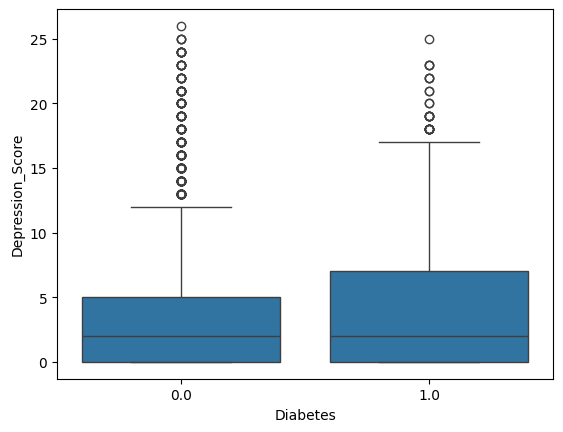

In [16]:
# 0 = no diabetes , 1 = diabetes
sns.boxplot(x="Diabetes", y="Depression_Score", data=df)

Diabetes group (1.0)
Mean ≈ 4.38
75th percentile = 7
More high-end values (longer upper tail)


No diabetes group (0.0)
Mean ≈ 3.49
75th percentile = 5
Slightly lower spread


People with diabetes tend to have higher depression scores overall, even though the “typical” (median) person in both groups scores the same.

In [17]:
print(diab_group.describe())
print(no_diab_group.describe())

count    650.000000
mean       4.383077
std        5.386111
min        0.000000
25%        0.000000
50%        2.000000
75%        7.000000
max       25.000000
Name: Depression_Score, dtype: float64
count    4168.000000
mean        3.491123
std         4.480651
min         0.000000
25%         0.000000
50%         2.000000
75%         5.000000
max        26.000000
Name: Depression_Score, dtype: float64


There is a statistically significant difference in depression scores between individuals with and without diabetes (p = 0.0052). Although the median score is the same in both groups (2.0), individuals with diabetes show a higher overall distribution of depression scores, with greater variability and more high-end values.

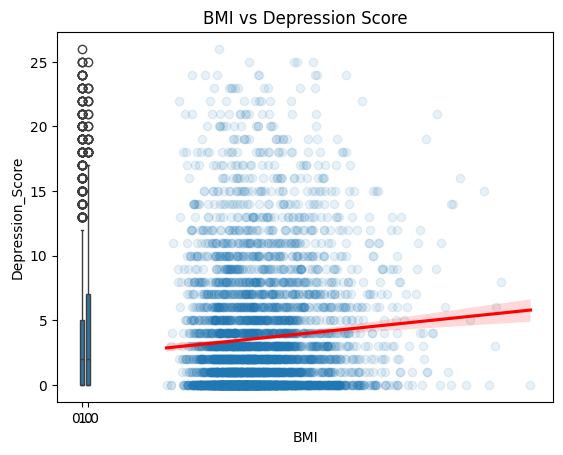

In [13]:
# ---------------------------------------------------------
# 5. Visualizations
# ---------------------------------------------------------

sns.boxplot(data=df, x="Diabetes", y="Depression_Score")
plt.title("Depression Score by Diabetes Status")
plt.savefig("depression_by_diabetes.png")

sns.regplot(data=df, x="BMI", y="Depression_Score",
            scatter_kws={"alpha": 0.1}, line_kws={"color": "red"})
plt.title("BMI vs Depression Score")
plt.savefig("bmi_vs_depression.png")


In [14]:
# ---------------------------------------------------------
# 6. Export for Tableau
# ---------------------------------------------------------

df.to_csv("nhanes_cleaned_for_tableau.csv", index=False)